# **Computational Intelligence for Optimization PROJECT - Group C36_Divergence**  

## **Table of Contents**

1. [Project Overview](#1-project-overview)
2. [Imports & Setup](#2-imports--setup)
3. [Load and Visualize target image](#3-load-visualize-target)
4. [Create a Random Individual](#4-random-individual)
5. [Mutation Tests](#5-mutation_tests)
6. [Crossover tests](#6-crossover)
7. [Limit Triangle Sizes](#7)
8. [Limit Alpha values](#8)
9. [Probabilities Tests](#9)
10. [Increase Population size and the number of generations](#10)
11. [Try to Increase Diversity](#11)
12. [Challenge 1 -- Perceptual Fitness (CIEDE2000)](#12)


## **1. Project Overview** <a id="1-project-overview"></a>

Vermeer's *Girl with a Pearl Earring* — Genetic Algorithm reconstruction with 100 colored triangles.

Each candidate solution (an `Individual`) is a list of 100 `Triangle` objects. Each triangle is encoded as 10 floats in [0, 1] — three (x, y) vertices plus an RGBA color — and decoded to pixel/byte space at render time. Fitness is pixel-wise RMSE between the rendered phenotype and the target image (minimization).

## **2. Imports & Setup** <a id="2-imports--setup"></a>

In [ ]:
# IMPORTS
# Standard
import random
import numpy as np
from time import time
from pathlib import Path
import pandas as pd
import itertools

# Image handling & rendering
from PIL import Image, ImageDraw

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Project modules
from solution import *
from operators import *
from ga import *
from utils import *

In [25]:
# REPRODUCIBILITY
SEED = 23
random.seed(SEED)
np.random.seed(SEED)

# SETTINGS
# Image canvas dimensions (fixed by project spec)
IMG_WIDTH  = 300
IMG_HEIGHT = 400
N_TRIANGLES = 100

## **3. Load and Visualize target image** <a id="3-load-visualize-target"></a>

In [26]:
# READ AND VISUALIZE TARGET IMAGE

IMAGE_PATH = Path("data/girl_pearl_earing.png")

# Load as RGB and convert to numpy array (H x W x 3, uint8)
target_img = Image.open(IMAGE_PATH).convert("RGB")
target_array = np.array(target_img, dtype=np.float32)  # float32 for fitness computation

print(f"Image loaded: {target_array.shape}, dtype={target_array.dtype}")
print(f"Pixel range: [{target_array.min():.0f}, {target_array.max():.0f}]")


Image loaded: (400, 300, 3), dtype=float32
Pixel range: [0, 255]


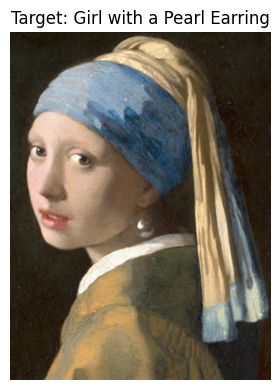

In [4]:
fig, axes = plt.subplots(1, 1, figsize=(3,4))

axes.imshow(target_img)
axes.set_title("Target: Girl with a Pearl Earring", fontsize=12)
axes.axis("off")
plt.tight_layout()
plt.show()


## **4. Create a Random Individual** <a id="4-random-individual"></a>

A baseline sanity check: build one random `Individual`, render it, and compute its RMSE against the target. This is the *random search* baseline that the GA must beat.

Random individual RMSE vs. target: 92.38


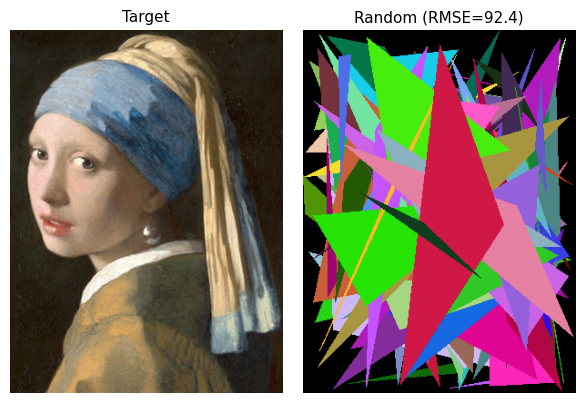

In [5]:
# Build a random Individual and evaluate it against the target.
rand_ind = Individual(target=target_array)
baseline_rmse = rand_ind.fitness()
print(f"Random individual RMSE vs. target: {baseline_rmse:.2f}")

# Side-by-side: target on the left, random phenotype on the right.
fig, axes = plt.subplots(1, 2, figsize=(6, 4))
axes[0].imshow(target_img)
axes[0].set_title("Target", fontsize=11)
axes[0].axis("off")
rand_ind.plot(ax=axes[1], title=f"Random (RMSE={baseline_rmse:.1f})")
plt.tight_layout()
plt.show()

## **5. Mutation Tests** <a id="5-mutation_tests"></a>


Experiment with different types of mutation and understand which ones works best for our problem.

In [ ]:
# 5. MUTATION TESTS
# Loop 1 — Mutation Type Comparison
# Compares triangle_mutation_vcf vs triangle_mutation_full
# Fixed hyperparameters; 5 runs per config

# CONFIG
POP_SIZE  = 300
MAX_GENS  = 100
XO_PROB   = 0
MUT_PROB  = 0.1
N_RUNS    = 5
ELITISM   = True

MUTATION_CONFIGS = [
    {"name": "VCF (vertex+color+order)", "fn": triangle_mutation_vcf},
    {"name": "Full (replace triangle)",  "fn": triangle_mutation_full},
]

In [ ]:
all_results_mut, all_curves_mut, best_inds_mut = run_experiment(
    configs = MUTATION_CONFIGS,
    target_array = target_array,
    n_runs = N_RUNS,
    max_gens = MAX_GENS,
    pop_size = POP_SIZE,
    seed = SEED,
    xo_prob = XO_PROB,
    mut_prob = MUT_PROB,
    elitism = ELITISM,
    selection_algorithm = tournament_selection,
    fixed_xo_fn=triangle_crossover,
    fixed_mut_fn=None,  # will be set per config
)

In [ ]:
df_mut = pd.DataFrame(all_results_mut)

summary_mut = (
    df_mut.groupby("mutation_type")[["best_fitness", "time_seconds"]]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
    .rename(columns={"mean": "avg", "std": "std", "min": "best", "max": "worst"})
)

print("\n SUMMARY")
print(summary_mut.to_string(index=False))


 SUMMARY
           mutation_type       avg      std      best     worst
 Full (replace triangle) 63.746831 1.879128 61.520386 65.285797
VCF (vertex+color+order) 61.981960 1.213918 60.607670 63.213772


In [ ]:
plot_experiment_summary(
    all_curves = all_curves_mut, 
    df = df_mut,
    configs = MUTATION_CONFIGS,
    config_key = "mutation_type",
    title_prefix = "Mutation"
)

In [ ]:
plot_best_individuals(best_inds = best_inds_mut, target_img = target_img)

## **6. Crossover tests**

In [ ]:
# Loop 3 — CONFIG
# Hyperparameters fixos (melhores do Loop 2)
POP_SIZE  = 200
MAX_GENS  = 5000
XO_PROB   = 0.9
MUT_PROB  = 0
N_RUNS    = 5
ELITISM   = True

CROSSOVER_CONFIGS = [
    {"name": "Uniform",           "fn": uniform_crossover},
    {"name": "K-Point (k=3–7)",   "fn": kpoint_crossover},
    {"name": "Reduced Surrogate", "fn": reduced_surrogate_crossover},
    {"name": "Shuffle",           "fn": shuffle_crossover},
]

print(f"Configs: {[c['name'] for c in CROSSOVER_CONFIGS]}")
print(f"Total runs: {len(CROSSOVER_CONFIGS) * N_RUNS}")


Configs: ['Uniform', 'K-Point (k=3–7)', 'Reduced Surrogate', 'Shuffle']
Total runs: 8


In [ ]:
all_results_xo, all_curves_xo, best_inds_xo = run_experiment(
    configs = CROSSOVER_CONFIGS,
    target_array = target_array,
    n_runs = N_RUNS,
    max_gens = MAX_GENS,
    pop_size = POP_SIZE,
    seed = SEED,
    xo_prob = XO_PROB,
    mut_prob = MUT_PROB,
    elitism = ELITISM,
    selection_algorithm = tournament_selection,
    fixed_xo_fn=None,  # will be set per config
    fixed_mut_fn=triangle_mutation_vcf,  # best from Loop 1 CHANGE IF IT CHANGES
)

In [ ]:
# Loop 3 — Summary table
df_xo = pd.DataFrame(all_results_xo)

summary_xo = (
    df_xo.groupby("crossover_type")[["best_fitness", "time_seconds"]]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
    .rename(columns={"mean": "avg", "std": "std", "min": "best", "max": "worst"})
    .sort_values("avg")
)

print("\n--- SUMMARY (sorted by avg RMSE, lower = better) ---")
print(summary_xo.to_string(index=False))



--- SUMMARY (sorted by avg RMSE, lower = better) ---
   crossover_type       avg      std      best     worst
          Uniform 30.195436 0.392956 29.917574 30.473297
          Shuffle 30.434930 1.563686 29.329237 31.540623
Reduced Surrogate 30.820390 1.414711 29.820038 31.820742
  K-Point (k=3–7) 31.098094 1.232122 30.226852 31.969336


In [ ]:
plot_experiment_summary(
    all_results = all_results_xo,
    df = df_xo,
    configs = CROSSOVER_CONFIGS,
    config_key = "crossover_type",
    title_prefix = "Crossover"
)

In [ ]:
plot_best_individuals(best_inds = best_inds_xo, target_img = target_img)

Try **Adaptive Crossover** in which the type of crossover will change with the generations.

In [ ]:
# ADAPTIVE CROSSOVER — Standalone Run
# Uniform (0–50%) -> K-Point (50–85%) -> Reduced Surrogate (85–100%)

POP_SIZE  = 200
MAX_GENS  = 5000
XO_PROB   = 0.9
MUT_PROB  = 0
N_RUNS    = 5
ELITISM   = True

In [ ]:
all_results_adp_xo, all_curves_adp_xo, best_inds_adp_xo = run_single_experiment(
    target_array= target_array,
    n_runs = N_RUNS,
    max_gens = MAX_GENS,
    pop_size = POP_SIZE,
    seed = SEED,
    xo_prob = XO_PROB,
    mut_prob = MUT_PROB,
    elitism = ELITISM,
    selection_algorithm = tournament_selection,
    xo_fn=adaptive_crossover_schedule,
    mut_fn=triangle_mutation_vcf,  # best from Loop 1 CHANGE IF IT CHANGES      
)

all_results_adp_xo 


  Adaptive Crossover — Run 1/2
  Gen  500/5000 | RMSE: 40.2986 | op: Uniform | 503.2s
  Gen 1000/5000 | RMSE: 35.2423 | op: Uniform | 1092.9s
  Gen 1500/5000 | RMSE: 33.3721 | op: K-Point | 1551.8s
  Gen 2000/5000 | RMSE: 32.2769 | op: K-Point | 1998.7s
  Gen 2500/5000 | RMSE: 31.7203 | op: K-Point | 2438.7s
  Gen 3000/5000 | RMSE: 31.2356 | op: K-Point | 2867.2s
  Gen 3500/5000 | RMSE: 30.9834 | op: Red.Surrogate | 3304.2s
  Gen 4000/5000 | RMSE: 30.6699 | op: Red.Surrogate | 3747.2s
  Gen 4500/5000 | RMSE: 30.5175 | op: Red.Surrogate | 4296.7s
  Gen 5000/5000 | RMSE: 30.3796 | op: Red.Surrogate | 4940.9s
  → Final RMSE: 30.3796

  Adaptive Crossover — Run 2/2
  Gen  500/5000 | RMSE: 42.8427 | op: Uniform | 595.5s
  Gen 1000/5000 | RMSE: 37.2163 | op: Uniform | 1012.6s
  Gen 1500/5000 | RMSE: 34.9945 | op: K-Point | 1440.0s
  Gen 2000/5000 | RMSE: 33.6309 | op: K-Point | 1916.8s
  Gen 2500/5000 | RMSE: 32.7860 | op: K-Point | 2353.7s
  Gen 3000/5000 | RMSE: 32.1151 | op: K-Point | 27

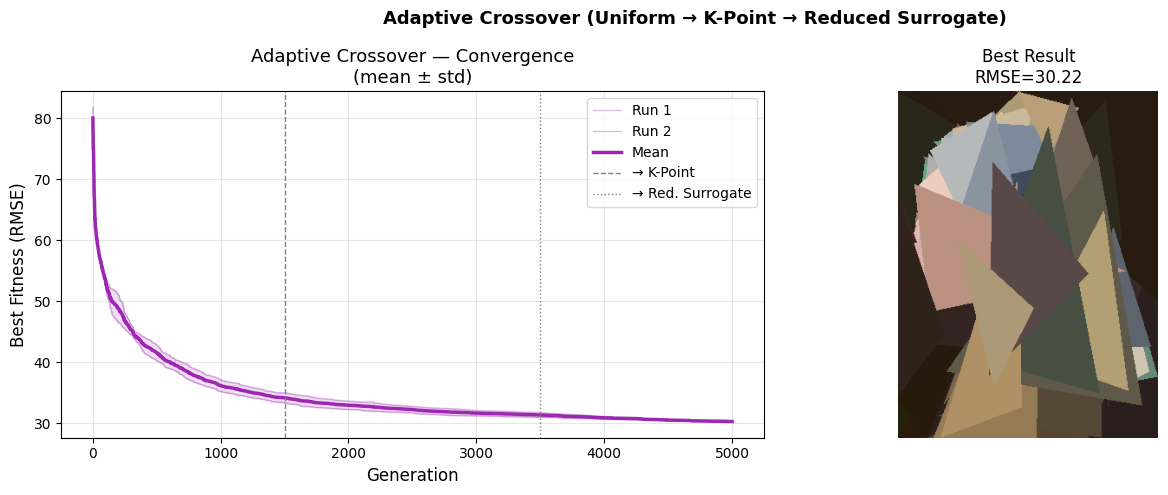

In [ ]:
gens = np.arange(1, MAX_GENS + 1)
curves = np.array(all_curves_adp_xo)   # (N_RUNS, MAX_GENS)
mean   = curves.mean(axis=0)
std    = curves.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Convergence curve (mean ± std) + runs individuais
ax = axes[0]
for i, curve in enumerate(all_curves_adp_xo):
    ax.plot(gens, curve, alpha=0.3, linewidth=1, color="#9C27B0", label=f"Run {i+1}")
ax.plot(gens, mean, color="#9C27B0", linewidth=2.5, label="Mean")
ax.fill_between(gens, mean - std, mean + std, alpha=0.15, color="#9C27B0")

# Linhas verticais a marcar os switches de operador
ax.axvline(MAX_GENS * 0.3, color="gray", linestyle="--", linewidth=1, label=" K-Point")
ax.axvline(MAX_GENS * 0.7, color="gray", linestyle=":",  linewidth=1, label=" Red. Surrogate")

ax.set_xlabel("Generation", fontsize=12)
ax.set_ylabel("Best Fitness (RMSE)", fontsize=12)
ax.set_title("Adaptive Crossover — Convergence\n(mean ± std)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2 — Best individual vs target
ax = axes[1]
ax.imshow(best_inds_adp_xo[0].render())
ax.set_title(f"Best Result\nRMSE={best_inds_adp_xo[0].fitness():.2f}", fontsize=12)
ax.axis("off")

fig.suptitle("Adaptive Crossover (Uniform → K-Point → Reduced Surrogate)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## **7. Limit Triangle Sizes** <a id="7"></a>

Constrain each triangle's bounding-box span to `MAX_TRIANGLE_SIZE` in normalised coordinates. Triangles that span the whole canvas hide the rest of the genome through alpha-blending and waste the limited 100-triangle budget, while very small triangles forfeit colour spread. We compare three settings of `MAX_TRIANGLE_SIZE` against the unconstrained baseline.


In [ ]:
# AUTOGEN_CIFO_SECTIONS_V1
# Section 7 -- size limit sweep.
# We monkey-patch solution.MAX_TRIANGLE_SIZE for each cell of the sweep,
# rebuild the initial population so the new constraint is enforced at
# construction, and run a short GA. Times are kept modest (200 gens, 80
# individuals, 3 runs) so the sweep is tractable on a single machine.

import importlib
import solution
import operators

POP_SIZE_S7 = 80
MAX_GENS_S7 = 200
XO_PROB_S7  = 0.9
MUT_PROB_S7 = 0.05
N_RUNS_S7   = 3
SIZE_LIMITS = [1.00, 0.40, 0.25, 0.15]   # 1.00 = unconstrained baseline

size_results = {}
size_curves  = {}
size_best    = {}

for size_limit in SIZE_LIMITS:
    print(f"\n=== MAX_TRIANGLE_SIZE = {size_limit:.2f} ===")
    # Monkey-patch the module-level constant so Triangle.__init__ picks it up
    solution.MAX_TRIANGLE_SIZE = size_limit
    # operators imports `shrink_to_max_size` from solution at module load.
    # Since shrink_to_max_size reads solution.MAX_TRIANGLE_SIZE at call time
    # we don't need to reimport operators.

    _, curves, best = run_single_experiment(
        target_array        = target_array,
        n_runs              = N_RUNS_S7,
        max_gens            = MAX_GENS_S7,
        pop_size            = POP_SIZE_S7,
        seed                = SEED,
        xo_prob             = XO_PROB_S7,
        mut_prob            = MUT_PROB_S7,
        elitism             = True,
        selection_algorithm = tournament_selection,
        xo_fn               = triangle_crossover,
        mut_fn              = triangle_mutation_vcf,
    )
    size_curves[size_limit]  = curves
    size_best[size_limit]    = best
    size_results[size_limit] = best.fitness()

# Restore default before continuing with later sections so other cells
# don't silently inherit the last value tested.
solution.MAX_TRIANGLE_SIZE = 0.25

print("\n--- Summary ---")
for s, f in sorted(size_results.items()):
    print(f"  MAX_TRIANGLE_SIZE={s:.2f}  ->  best fitness {f:.3f}")


In [ ]:
# Convergence curves per size limit + best individual gallery.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ["#9C27B0", "#2196F3", "#4CAF50", "#F44336"]
for color, size_limit in zip(colors, SIZE_LIMITS):
    curves = np.array(size_curves[size_limit])
    mean   = curves.mean(axis=0)
    gens   = np.arange(1, len(mean) + 1)
    axes[0].plot(gens, mean, color=color, linewidth=2,
                 label=f"size={size_limit:.2f}")
axes[0].set_xlabel("Generation"); axes[0].set_ylabel("Best Fitness (RMSE)")
axes[0].set_title("Convergence by MAX_TRIANGLE_SIZE")
axes[0].grid(alpha=0.3); axes[0].legend()

best_limit = min(size_results, key=size_results.get)
axes[1].imshow(size_best[best_limit].render())
axes[1].set_title(f"Best (size={best_limit:.2f}) | RMSE={size_results[best_limit]:.2f}")
axes[1].axis("off")
plt.tight_layout(); plt.show()


## **8. Limit Alpha values** <a id="8"></a>

Clip each triangle's alpha channel to a window `[ALPHA_MIN, ALPHA_MAX]`. `alpha=0` makes the triangle invisible -- a wasted gene block -- while `alpha=1` makes it fully opaque and hides everything below it, defeating the alpha-blending stacking that the rendered painting relies on. We compare three windows against the unconstrained `[0, 1]` baseline.


In [ ]:
# Section 8 -- alpha window sweep. Same protocol as Section 7.
POP_SIZE_S8 = 80
MAX_GENS_S8 = 200
XO_PROB_S8  = 0.9
MUT_PROB_S8 = 0.05
N_RUNS_S8   = 3
ALPHA_WINDOWS = [(0.00, 1.00), (0.20, 0.90), (0.30, 0.80), (0.50, 0.70)]

alpha_results = {}
alpha_curves  = {}
alpha_best    = {}

for amin, amax in ALPHA_WINDOWS:
    print(f"\n=== ALPHA window [{amin:.2f}, {amax:.2f}] ===")
    solution.ALPHA_MIN = amin
    solution.ALPHA_MAX = amax

    _, curves, best = run_single_experiment(
        target_array        = target_array,
        n_runs              = N_RUNS_S8,
        max_gens            = MAX_GENS_S8,
        pop_size            = POP_SIZE_S8,
        seed                = SEED,
        xo_prob             = XO_PROB_S8,
        mut_prob            = MUT_PROB_S8,
        elitism             = True,
        selection_algorithm = tournament_selection,
        xo_fn               = triangle_crossover,
        mut_fn               = triangle_mutation_vcf,
    )
    key = (amin, amax)
    alpha_curves[key]  = curves
    alpha_best[key]    = best
    alpha_results[key] = best.fitness()

# Restore project defaults.
solution.ALPHA_MIN = 0.30
solution.ALPHA_MAX = 0.80

print("\n--- Summary ---")
for k, f in sorted(alpha_results.items()):
    print(f"  ALPHA={k}  ->  best fitness {f:.3f}")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ["#9C27B0", "#2196F3", "#4CAF50", "#F44336"]
for color, key in zip(colors, ALPHA_WINDOWS):
    curves = np.array(alpha_curves[key])
    mean = curves.mean(axis=0)
    axes[0].plot(np.arange(1, len(mean) + 1), mean, color=color, linewidth=2,
                 label=f"alpha=[{key[0]:.2f},{key[1]:.2f}]")
axes[0].set_xlabel("Generation"); axes[0].set_ylabel("Best Fitness (RMSE)")
axes[0].set_title("Convergence by Alpha Window")
axes[0].grid(alpha=0.3); axes[0].legend()

best_window = min(alpha_results, key=alpha_results.get)
axes[1].imshow(alpha_best[best_window].render())
axes[1].set_title(f"Best alpha={best_window} | RMSE={alpha_results[best_window]:.2f}")
axes[1].axis("off")
plt.tight_layout(); plt.show()


## **9. Probabilities Tests** <a id="9"></a>

Test different values for the probabilities of crossover and mutation

In [ ]:
# 6. HYPERPARAMETER SEARCH — Mutation & Crossover Probabilities
# Loop 2 — Grid search over mut_prob x xo_prob
# Mutation type and crossover type fixed: triangle_mutation_vcf + triangle_crossover (winners from Loops 1 & 2)

# CONFIG
POP_SIZE  = 200
MAX_GENS  = 100
N_RUNS    = 5
ELITISM   = True

MUT_PROBS = [0.01, 0.05, 0.15]
XO_PROBS  = [0.7, 0.8, 0.9, 0.95]

# Total combinations
PROB_CONFIGS = list(itertools.product(MUT_PROBS, XO_PROBS))
print(f"Total configurations: {len(PROB_CONFIGS)}  |  Total runs: {len(PROB_CONFIGS) * N_RUNS}")

Total configurations: 12  |  Total runs: 60


In [ ]:
all_results_prob, all_curves_prob, best_inds_prob = run_experiment(
    configs = PROB_CONFIGS,
    target_array = target_array,
    n_runs = N_RUNS,
    max_gens = MAX_GENS,
    pop_size = POP_SIZE,
    seed = SEED,
    xo_prob = None,  # will be set per config
    mut_prob = None, # will be set per config
    elitism = ELITISM,
    selection_algorithm = tournament_selection,
    fixed_xo_fn = triangle_crossover,  # best from Loop 2 CHANGE IF IT CHANGES
    fixed_mut_fn = triangle_mutation_vcf,  # best from Loop 1 CHANGE IF IT CHANGES
)


  mut_prob=0.01  |  xo_prob=0.7

 Run 1/5
-------------- Generation: 1/100, duration: 0.00s --------------
-------------- Generation: 2/100, duration: 1.42s --------------
-------------- Generation: 3/100, duration: 2.13s --------------
-------------- Generation: 4/100, duration: 2.81s --------------
-------------- Generation: 5/100, duration: 3.50s --------------
-------------- Generation: 6/100, duration: 4.35s --------------
-------------- Generation: 7/100, duration: 5.35s --------------
-------------- Generation: 8/100, duration: 6.53s --------------
-------------- Generation: 9/100, duration: 7.69s --------------
-------------- Generation: 10/100, duration: 8.83s --------------
-------------- Generation: 11/100, duration: 9.89s --------------
-------------- Generation: 12/100, duration: 10.89s --------------
-------------- Generation: 13/100, duration: 11.63s --------------
-------------- Generation: 14/100, duration: 12.25s --------------
-------------- Generation: 15/100, dura

KeyboardInterrupt: 

In [ ]:
df_prob = pd.DataFrame(all_results_prob)

summary_prob = (
    df_prob.groupby(["mut_prob", "xo_prob"])[["best_fitness", "time_seconds"]]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
    .rename(columns={"mean": "avg", "std": "std", "min": "best", "max": "worst"})
    .sort_values("avg")
)

print("\n--- SUMMARY (sorted by avg fitness) ---")
print(summary_prob.to_string(index=False))


--- SUMMARY (sorted by avg fitness) ---
 mut_prob  xo_prob       avg      std      best     worst
     0.01      0.9 54.308427 1.249750 53.203495 56.111851
     0.01      1.0 54.588148 1.453046 53.074635 56.767540
     0.01      0.7 55.065352 2.035259 53.045868 58.007637
     0.05      1.0 55.852828 0.355356 55.522842 56.297390
     0.05      0.9 56.574843 1.823049 54.035435 58.519836
     0.05      0.7 57.536569 1.380509 55.749691 59.273796
     0.15      0.7 62.511581 2.308225 60.288948 65.440895
     0.15      1.0 62.751076 2.171997 59.714546 64.900978
     0.15      0.9 64.041627 2.548438 60.104031 67.083687


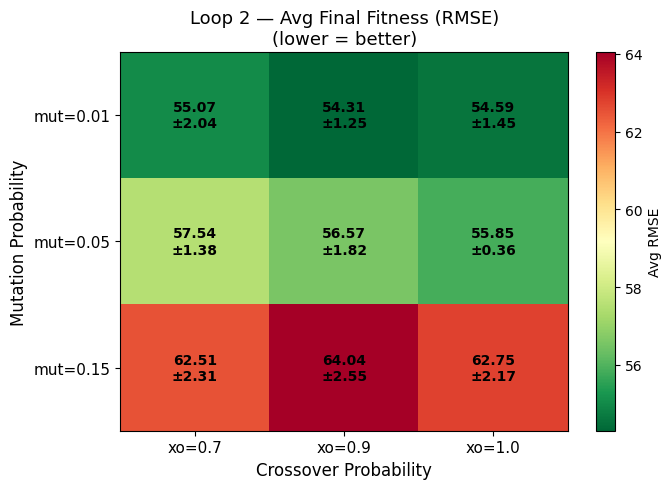

In [ ]:
# Plot 1 — Heatmap of average final fitness (mut_prob x xo_prob)
pivot = summary_prob.pivot(index="mut_prob", columns="xo_prob", values="avg")

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto")

ax.set_xticks(range(len(XO_PROBS)))
ax.set_yticks(range(len(MUT_PROBS)))
ax.set_xticklabels([f"xo={v}" for v in pivot.columns], fontsize=11)
ax.set_yticklabels([f"mut={v}" for v in pivot.index], fontsize=11)
ax.set_xlabel("Crossover Probability", fontsize=12)
ax.set_ylabel("Mutation Probability", fontsize=12)
ax.set_title("Avg Final Fitness (RMSE)\n(lower = better)", fontsize=13)

# Annotate each cell with mean ± std
for i, mut in enumerate(pivot.index):
    for j, xo in enumerate(pivot.columns):
        avg = summary_prob.loc[(summary_prob.mut_prob == mut) & (summary_prob.xo_prob == xo), "avg"].values[0]
        std = summary_prob.loc[(summary_prob.mut_prob == mut) & (summary_prob.xo_prob == xo), "std"].values[0]
        ax.text(j, i, f"{avg:.2f}\n±{std:.2f}", ha="center", va="center",
                fontsize=10, color="black", fontweight="bold")

plt.colorbar(im, ax=ax, label="Avg RMSE")
plt.tight_layout()
plt.show()

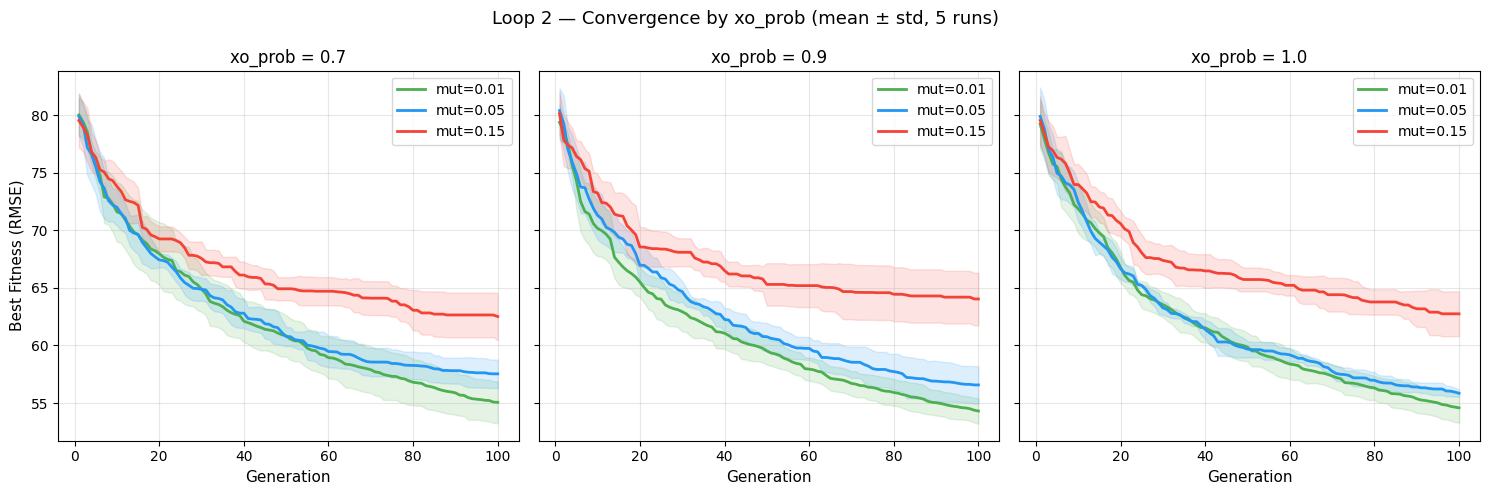

In [ ]:
# Plot 2 — Convergence curves grouped by xo_prob (one subplot per xo_prob)
# Each subplot shows the 3 mut_prob curves (mean only, for readability)
colors_mut = {0.01: "#4CAF50", 0.05: "#2196F3", 0.15: "#F44336"}
gens = np.arange(1, MAX_GENS + 1)

fig, axes = plt.subplots(1, len(XO_PROBS), figsize=(15, 5), sharey=True)

for ax, xo_prob in zip(axes, XO_PROBS):
    for mut_prob in MUT_PROBS:
        curves = np.array(all_curves_prob[(mut_prob, xo_prob)])  # shape: (N_RUNS, MAX_GENS)
        mean   = curves.mean(axis=0)
        std    = curves.std(axis=0)
        color  = colors_mut[mut_prob]

        ax.plot(gens, mean, label=f"mut={mut_prob}", color=color, linewidth=2)
        ax.fill_between(gens, mean - std, mean + std, alpha=0.15, color=color)

    ax.set_title(f"xo_prob = {xo_prob}", fontsize=12)
    ax.set_xlabel("Generation", fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

axes[0].set_ylabel("Best Fitness (RMSE)", fontsize=11)
fig.suptitle("Convergence by xo_prob (mean ± std, 5 runs)", fontsize=13)
plt.tight_layout()
plt.show()

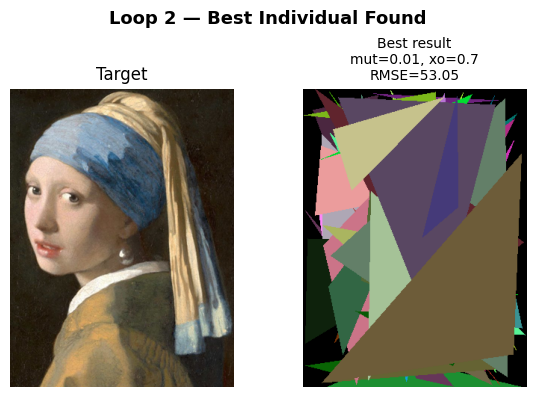

In [ ]:
# Best combination found
best_config = min(all_results_prob, key=lambda x: x["best_fitness"])["config"]

plot_best_individuals(
    best_inds=best_inds_prob,
    configs=[best_config],   # list with only one config
    target_img=target_img,
    title_prefix="Best Probability Configuration"
)

## **10. Increase Population size and the number of generations** <a id="10"></a>

We try to improve fitness by increasing the size of the Population and the Number of generations when running the genetic algorithm. We use the best crossover and mutation functions as well as the 2 best probability combinations.

### **XO_PROB   = 0.9** e **MUT_PROB  = 0.01**

In [ ]:
# 7. Final Run
# Best hyperparameters from Loop 1 & 2:
#   - Mutation type : triangle_mutation_vcf
#   - mut_prob      : 0.05
#   - xo_prob       : 1.0
# Population: 50 | Generations: 500 | Elitism: True
# Saves convergence curve + evolution snapshots every 100 generations

# CONFIG
POP_SIZE  = 500
MAX_GENS  = 5000
XO_PROB   = 0.9
MUT_PROB  = 0.01
ELITISM   = True


In [ ]:
all_results_1, all_curves_1, best_ind_1 = run_single_experiment(
    target_array = target_array,
    max_gens = MAX_GENS,
    pop_size = POP_SIZE,
    seed = SEED,
    xo_prob = XO_PROB,
    mut_prob = MUT_PROB,
    elitism = ELITISM,
    selection_algorithm = tournament_selection,
    xo_fn = triangle_crossover,  # best from Loop 2 CHANGE IF IT CHANGES
    mut_fn = triangle_mutation_vcf,  # best from Loop 1 CHANGE IF IT CHANGES
)

all_results_1

Starting final run: 500 individuals x 5000 generations
Hyperparameters: mut_prob=0.01, xo_prob=0.9
Snapshots every 100 generations

  Gen 100/5000 | Best RMSE: 52.6431 | Elapsed: 172.9s
  Gen 200/5000 | Best RMSE: 48.8945 | Elapsed: 352.3s
  Gen 300/5000 | Best RMSE: 46.3924 | Elapsed: 531.9s
  Gen 400/5000 | Best RMSE: 44.3709 | Elapsed: 712.4s
  Gen 500/5000 | Best RMSE: 42.8331 | Elapsed: 896.5s
  Gen 600/5000 | Best RMSE: 41.7870 | Elapsed: 1089.0s
  Gen 700/5000 | Best RMSE: 40.9208 | Elapsed: 1278.6s
  Gen 800/5000 | Best RMSE: 39.7180 | Elapsed: 1467.0s
  Gen 900/5000 | Best RMSE: 38.9635 | Elapsed: 1657.1s
  Gen 1000/5000 | Best RMSE: 37.4180 | Elapsed: 1847.4s
  Gen 1100/5000 | Best RMSE: 36.0818 | Elapsed: 2036.0s
  Gen 1200/5000 | Best RMSE: 35.0972 | Elapsed: 2224.9s
  Gen 1300/5000 | Best RMSE: 34.6535 | Elapsed: 2420.0s
  Gen 1400/5000 | Best RMSE: 34.1878 | Elapsed: 2614.1s
  Gen 1500/5000 | Best RMSE: 33.6635 | Elapsed: 2807.0s
  Gen 1600/5000 | Best RMSE: 33.3320 | Ela

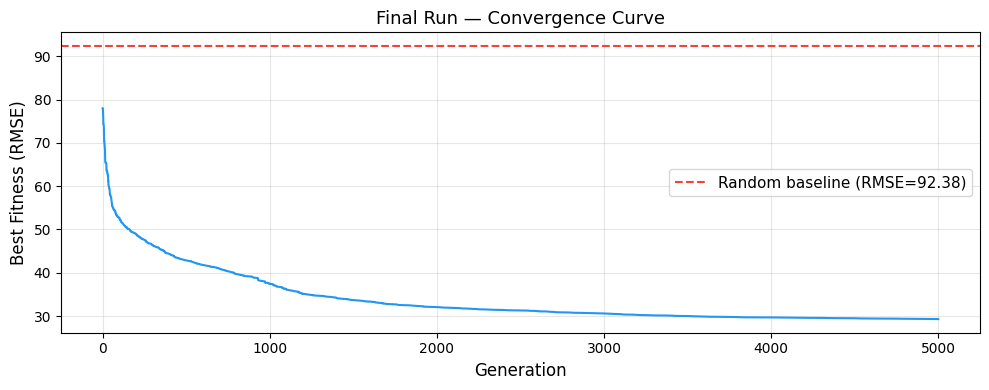

In [ ]:
plot_convergence_curve(
    fitness_curve= all_curves_1[0],
    baseline_rmse= baseline_rmse,
    MAX_GENS= MAX_GENS
)

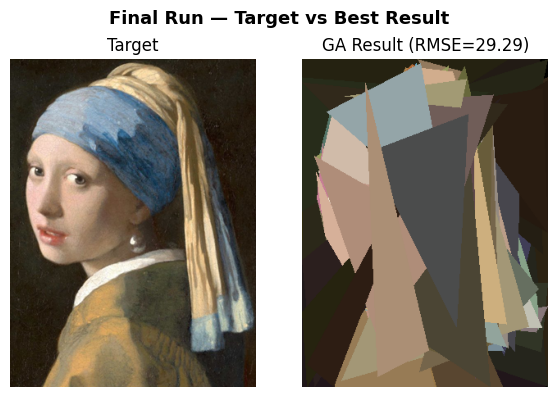

In [ ]:
plot_best_individuals(
    best_inds = best_ind_1,
    configs = None,
    target_img = target_img,
    title_prefix = "Best Individual"
)

### **XO_PROB   = 0.7** and **MUT_PROB  = 0.05**

In [ ]:
# 7. Final Run
# Best hyperparameters from Loop 1 & 2:
#   - Mutation type : triangle_mutation_vcf
#   - mut_prob      : 0.05
#   - xo_prob       : 1.0
# Population: 50 | Generations: 500 | Elitism: True
# Saves convergence curve + evolution snapshots every 100 generations

# CONFIG
POP_SIZE  = 200
MAX_GENS  = 5000
XO_PROB   = 0.7
MUT_PROB  = 0.01
ELITISM   = True

In [ ]:
all_results_2, all_curves_2, best_inds_2 = run_single_experiment(
    target_array = target_array,
    n_runs = N_RUNS,
    max_gens = MAX_GENS,
    pop_size = POP_SIZE,
    seed = SEED,
    xo_prob = XO_PROB,
    mut_prob = MUT_PROB,
    elitism = ELITISM,
)

all_results_2

In [ ]:
plot_convergence_curve(
    fitness_curve= all_curves_2[0],
    baseline_rmse= baseline_rmse,
    MAX_GENS= MAX_GENS
)

In [ ]:
plot_best_individuals(
    best_inds = best_inds_2,
    configs = None,
    target_img = target_img,
    title_prefix = "Best Individual"
)

## **11. Try to Increase Diversity** <a id="11"></a>

Two anti-convergence mechanisms compared head-to-head against the static-mutation baseline:

- **Adaptive mutation (Rechenberg 1/5 success rule, 1973).** Track the fraction of offspring that beat their parents over a 10-generation window and scale `mut_prob` up if more than 1/5 succeed, down otherwise.
- **Diversity injection.** When the std of fitness drops below 50% of its initial value, replace the worst 20% of the population with fresh random individuals.


In [ ]:
POP_SIZE_S11 = 100
MAX_GENS_S11 = 300
XO_PROB_S11  = 0.9
MUT_PROB_S11 = 0.05
N_RUNS_S11   = 3

DIVERSITY_CONFIGS = {
    "baseline":             dict(),
    "adaptive mutation":    dict(adaptive_mutation=True),
    "diversity injection":  dict(diversity_injection=True),
    "adaptive + injection": dict(adaptive_mutation=True, diversity_injection=True),
}
div_results = {}
div_curves  = {}
div_best    = {}

for name, ga_kwargs in DIVERSITY_CONFIGS.items():
    print(f"\n=== {name} ===")
    _, curves, best = run_single_experiment(
        target_array        = target_array,
        n_runs              = N_RUNS_S11,
        max_gens            = MAX_GENS_S11,
        pop_size            = POP_SIZE_S11,
        seed                = SEED,
        xo_prob             = XO_PROB_S11,
        mut_prob            = MUT_PROB_S11,
        elitism             = True,
        selection_algorithm = tournament_selection,
        xo_fn               = triangle_crossover,
        mut_fn              = triangle_mutation_vcf,
        **ga_kwargs,
    )
    div_results[name] = best.fitness()
    div_curves[name]  = curves
    div_best[name]    = best

print("\n--- Summary ---")
for n, f in sorted(div_results.items(), key=lambda kv: kv[1]):
    print(f"  {n:25s} -> best fitness {f:.3f}")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = ["#9E9E9E", "#2196F3", "#4CAF50", "#F44336"]
for color, name in zip(colors, DIVERSITY_CONFIGS):
    curves = np.array(div_curves[name])
    mean = curves.mean(axis=0)
    axes[0].plot(np.arange(1, len(mean) + 1), mean, color=color, linewidth=2, label=name)
axes[0].set_xlabel("Generation"); axes[0].set_ylabel("Best Fitness (RMSE)")
axes[0].set_title("Convergence by Diversity Mechanism"); axes[0].grid(alpha=0.3); axes[0].legend()

best_name = min(div_results, key=div_results.get)
axes[1].imshow(div_best[best_name].render())
axes[1].set_title(f"Best: {best_name} | RMSE={div_results[best_name]:.2f}")
axes[1].axis("off")
plt.tight_layout(); plt.show()


## **12. Challenge 1 -- Perceptual Fitness (CIEDE2000)** <a id="12"></a>

Raw RGB RMSE weighs every channel error equally, but the human visual system is more sensitive to luminance shifts than to small chroma changes. CIE Lab is approximately perceptually uniform, and **CIEDE2000** (Sharma, Wu & Dalal 2005) corrects the residual non-uniformities of Lab around the blue and grey regions.

We re-run the GA with `fitness_metric="ciede2000"`. Note that the two metrics are on different scales -- we compare them by re-evaluating the *same* CIEDE2000 winner under the RMSE metric (and vice-versa) and by looking at the rendered images side by side.


In [ ]:
# Section 12 -- Challenge 1 (CIEDE2000 perceptual fitness).
POP_SIZE_S12 = 100
MAX_GENS_S12 = 300
XO_PROB_S12  = 0.9
MUT_PROB_S12 = 0.05
N_RUNS_S12   = 2

print("=== RMSE GA (baseline) ===")
_, curves_rmse, best_rmse = run_single_experiment(
    target_array=target_array, n_runs=N_RUNS_S12, max_gens=MAX_GENS_S12,
    pop_size=POP_SIZE_S12, seed=SEED, xo_prob=XO_PROB_S12,
    mut_prob=MUT_PROB_S12, elitism=True,
    selection_algorithm=tournament_selection,
    xo_fn=triangle_crossover, mut_fn=triangle_mutation_vcf,
    fitness_metric="rmse",
)

print("\n=== CIEDE2000 GA (challenge) ===")
_, curves_ciede, best_ciede = run_single_experiment(
    target_array=target_array, n_runs=N_RUNS_S12, max_gens=MAX_GENS_S12,
    pop_size=POP_SIZE_S12, seed=SEED, xo_prob=XO_PROB_S12,
    mut_prob=MUT_PROB_S12, elitism=True,
    selection_algorithm=tournament_selection,
    xo_fn=triangle_crossover, mut_fn=triangle_mutation_vcf,
    fitness_metric="ciede2000",
)

# Cross-evaluate: re-score each winner on the *other* metric using the
# same rendered phenotype, so the comparison is fair.
from solution import rgb_to_lab, ciede2000

rendered_rmse  = np.asarray(best_rmse.render(), dtype=np.float32)
rendered_ciede = np.asarray(best_ciede.render(), dtype=np.float32)
target_lab = rgb_to_lab(target_array)

rmse_of_rmse_winner   = float(np.sqrt(np.mean((rendered_rmse  - target_array) ** 2)))
rmse_of_ciede_winner  = float(np.sqrt(np.mean((rendered_ciede - target_array) ** 2)))
ciede_of_rmse_winner  = float(np.mean(ciede2000(rgb_to_lab(rendered_rmse),  target_lab)))
ciede_of_ciede_winner = float(np.mean(ciede2000(rgb_to_lab(rendered_ciede), target_lab)))

print("\n--- Cross-metric comparison ---")
print(f"  RMSE winner  -> RMSE {rmse_of_rmse_winner:.2f} | CIEDE2000 {ciede_of_rmse_winner:.2f}")
print(f"  CIEDE winner -> RMSE {rmse_of_ciede_winner:.2f} | CIEDE2000 {ciede_of_ciede_winner:.2f}")


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(target_img); axes[0].set_title("Target"); axes[0].axis("off")
axes[1].imshow(best_rmse.render())
axes[1].set_title(f"RMSE-optimised\nRMSE={rmse_of_rmse_winner:.1f} | dE={ciede_of_rmse_winner:.1f}")
axes[1].axis("off")
axes[2].imshow(best_ciede.render())
axes[2].set_title(f"CIEDE2000-optimised\nRMSE={rmse_of_ciede_winner:.1f} | dE={ciede_of_ciede_winner:.1f}")
axes[2].axis("off")
plt.tight_layout(); plt.show()
